# Домашнее задание — часть 2

Реализации из `homework_modules.ipynb`: оптимизатор, мультирегрессия (FCNN), MNIST (CNN), автоэнкодер.

**Что есть:** синтетическая мультирегрессия + **California housing**; метрики и лоссы; графики; cosine+warmup; early stopping; **чекпоинты**; смена оптимизатора/лосса (регрессия) и **смена оптимизатора на MNIST и AE**; разные активации; LogSoftMax и вариант **SoftMax**; в AE — **Dropout**, **PSNR** на тесте.


In [7]:
import pathlib
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

ROOT = pathlib.Path.cwd()
nb_path = ROOT / "homework_modules.ipynb"
ns = {"np": np, "numpy": np}
for cell in json.loads(nb_path.read_text(encoding="utf-8"))["cells"]:
    if cell.get("cell_type") != "code":
        continue
    src = "".join(cell.get("source", []))
    if not src.strip() or src.strip().startswith("%run"):
        continue
    exec(compile(src, str(nb_path), "exec"), ns)
for _k, _v in ns.items():
    if _k.startswith("_"):
        continue
    globals()[_k] = _v

print("Loaded:", [k for k in ns if not k.startswith("_") and k[:1].isupper()][:8], "...")


Loaded: ['Module', 'Sequential', 'Linear', 'SoftMax', 'LogSoftMax', 'BatchNormalization', 'ChannelwiseScaling', 'Dropout'] ...


In [8]:
# Дополнительные модули (в задании не требовались явно)

class Sigmoid(Module):
    def updateOutput(self, input):
        x = np.clip(input, -500, 500)
        self.output = 1.0 / (1.0 + np.exp(-x))
        return self.output

    def updateGradInput(self, input, gradOutput):
        s = self.output
        self.gradInput = gradOutput * s * (1.0 - s)
        return self.gradInput

    def __repr__(self):
        return "Sigmoid"


class Reshape(Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def updateOutput(self, input):
        self._in_shape = input.shape
        self.output = input.reshape(input.shape[0], *self.shape)
        return self.output

    def updateGradInput(self, input, gradOutput):
        self.gradInput = gradOutput.reshape(self._in_shape)
        return self.gradInput

    def __repr__(self):
        return "Reshape" + str(self.shape)


class NearestUpsample2d(Module):
    def __init__(self, scale_factor):
        super().__init__()
        self.s = int(scale_factor)

    def updateOutput(self, input):
        s = self.s
        self.output = np.repeat(np.repeat(input, s, axis=2), s, axis=3)
        return self.output

    def updateGradInput(self, input, gradOutput):
        N, C, H, W = input.shape
        s = self.s
        g = gradOutput.reshape(N, C, H, s, W, s).sum(axis=(3, 5))
        self.gradInput = g
        return self.gradInput

    def __repr__(self):
        return "NearestUpsample2d"



In [9]:
def build_fc_regression(n_in, n_out, hidden, p_drop, act_ctor):
    """FCNN: Linear -> BN -> ChannelwiseScaling -> Act -> Dropout -> ... -> Linear."""
    net = Sequential()
    prev = n_in
    for h in hidden:
        net.add(Linear(prev, h))
        net.add(BatchNormalization(alpha=0.9))
        net.add(ChannelwiseScaling(h))
        net.add(act_ctor())
        net.add(Dropout(p_drop))
        prev = h
    net.add(Linear(prev, n_out))
    return net


def save_checkpoint_npz(path, model):
    """Сохранить все параметры модели в .npz (arr_0, arr_1, ...)."""
    flat = copy_flat_params(model)
    np.savez_compressed(str(path), *flat)


def load_checkpoint_npz(path, model):
    z = np.load(path)
    flat = [z[k] for k in sorted(z.files)]
    load_flat_params(model, flat)


def run_regression_experiment(
    name,
    model,
    X_tr,
    y_tr,
    X_va,
    y_va,
    X_te,
    y_te,
    criterion,
    base_lr,
    epochs,
    batch_size,
    warmup_steps,
    early,
    optimizer_ctor,
    switch_epoch=None,
    switch_optimizer_ctor=None,
    switch_criterion=None,
    early_on="loss",
    checkpoint_path=None,
):
    opt = optimizer_ctor(model)
    crit = criterion
    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_r2": [], "lr": []}
    total_steps = max(1, epochs * (len(X_tr) // batch_size))
    step = 0
    best_state = None
    es = EarlyStopping(patience=early, min_delta=1e-5)

    for ep in range(epochs):
        if switch_epoch is not None and ep == switch_epoch and switch_optimizer_ctor is not None:
            opt = switch_optimizer_ctor(model)
            if switch_criterion is not None:
                crit = switch_criterion
            es = EarlyStopping(patience=early, min_delta=1e-5)
            print(f"  [{name}] switch at epoch {ep}: optimizer/criterion (early stopping reset)")

        perm = np.random.permutation(len(X_tr))
        Xs, ys = X_tr[perm], y_tr[perm]
        tr_losses = []
        for i in range(0, len(Xs), batch_size):
            xb = Xs[i : i + batch_size]
            yb = ys[i : i + batch_size]
            lr_now = lr_cosine_with_warmup(step, base_lr, warmup_steps, total_steps)
            opt.lr = lr_now
            tr_losses.append(train_batch(model, xb, yb, crit, opt))
            step += 1
        vl, mae, r2 = evaluate_regression(model, X_va, y_va, crit)
        history["train_loss"].append(float(np.mean(tr_losses)))
        history["val_loss"].append(vl)
        history["val_mae"].append(mae)
        history["val_r2"].append(r2)
        history["lr"].append(opt.lr)
        if early_on == "loss":
            monitor = vl
        else:
            monitor = -r2
        if es.is_better(monitor):
            best_state = copy_flat_params(model)
            if checkpoint_path is not None:
                save_checkpoint_npz(checkpoint_path, model)
        if es.should_stop():
            print(f"  [{name}] early stop at epoch {ep}")
            break

    if best_state is not None:
        load_flat_params(model, best_state)
    te_loss, te_mae, te_r2 = evaluate_regression(model, X_te, y_te, crit)
    return history, {"test_loss": te_loss, "test_mae": te_mae, "test_r2": te_r2}



Training small_relu [64, 32]
  [small_relu] switch at epoch 20: optimizer/criterion (early stopping reset)
  test: {'test_loss': 0.0982207204779556, 'test_mae': 0.0982207204779556, 'test_r2': 0.9851329016591689}
Training medium_leaky [256, 128, 64]
  [medium_leaky] switch at epoch 20: optimizer/criterion (early stopping reset)
  test: {'test_loss': 0.0699957367978744, 'test_mae': 0.0699957367978744, 'test_r2': 0.992526419512997}
Training large_elu [512, 256, 128, 64]
  [large_elu] early stop at epoch 16
  test: {'test_loss': 2.0947711603357613, 'test_mae': 0.5769235225149236, 'test_r2': 0.4981380808731931}


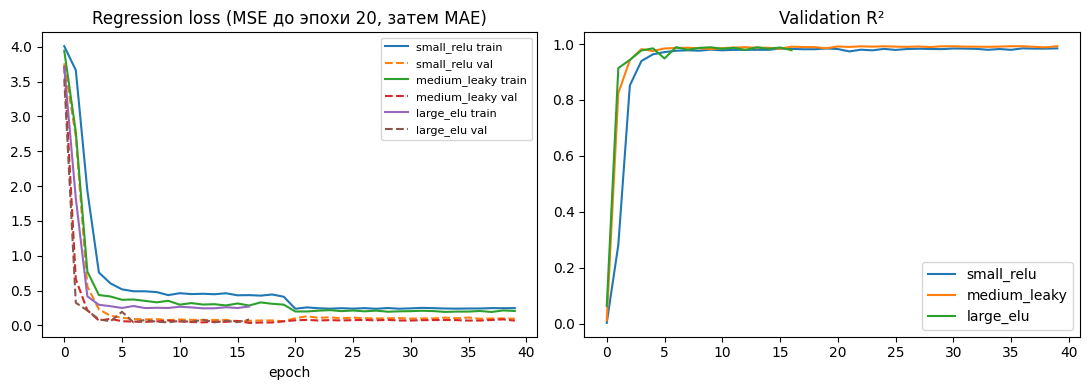

In [10]:
# --- 1) Мультирегрессия (синтетика sklearn), MSE / MAE, три размера сети ---
# Разные активации: ReLU / LeakyReLU / ELU; чекпоинты на диске; early stopping по val loss.

CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

np.random.seed(0)
X, y = make_regression(
    n_samples=4000,
    n_features=16,
    n_targets=4,
    noise=12.0,
    random_state=0,
)
y = y.astype(np.float32)
sc_x = StandardScaler()
sc_y = StandardScaler()
X = sc_x.fit_transform(X).astype(np.float32)
y = sc_y.fit_transform(y).astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

configs = [
    ("small_relu", [64, 32], lambda: ReLU()),
    ("medium_leaky", [256, 128, 64], lambda: LeakyReLU(0.01)),
    ("large_elu", [512, 256, 128, 64], lambda: ELU(1.0)),
]

reg_results = {}
EPOCHS_REG = 40
BATCH = 64
WARM = 200
for tag, hidden, act_ctor in configs:
    print("Training", tag, hidden)
    m = build_fc_regression(16, 4, hidden, 0.25, act_ctor)
    m.train()
    hist, test_m = run_regression_experiment(
        tag,
        m,
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        MSECriterion(),
        base_lr=3e-3,
        epochs=EPOCHS_REG,
        batch_size=BATCH,
        warmup_steps=WARM,
        early=10,
        optimizer_ctor=lambda mod: Adam(mod, lr=3e-3),
        switch_epoch=20,
        switch_optimizer_ctor=lambda mod: SGD(mod, lr=5e-2, momentum=0.85),
        switch_criterion=MAECriterion(),
        early_on="loss",
        checkpoint_path=CKPT_DIR / ("reg_" + tag + ".npz"),
    )
    reg_results[tag] = (hist, test_m)
    print("  test:", test_m)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for tag, (hist, _) in reg_results.items():
    ax[0].plot(hist["train_loss"], label=f"{tag} train")
    ax[0].plot(hist["val_loss"], "--", label=f"{tag} val")
ax[0].set_title("Regression loss (MSE до эпохи 20, затем MAE)")
ax[0].set_xlabel("epoch")
ax[0].legend(fontsize=8)
for tag, (hist, _) in reg_results.items():
    ax[1].plot(hist["val_r2"], label=tag)
ax[1].set_title("Validation R²")
ax[1].legend()
plt.tight_layout()
plt.show()



### 1b) Регрессия на реальных данных (California housing)

Синтетика `make_regression` выше — удобна для **мульти**регрессии (несколько целей). Ниже один скалярный таргет (медианная цена), чтобы явно попасть в формулировку «на выбранных вами данных» из задания.


  [california_housing] early stop at epoch 7
California housing test: {'test_loss': 0.63785076405535, 'test_mae': 0.6467014592662645, 'test_r2': 0.3414008653362941}


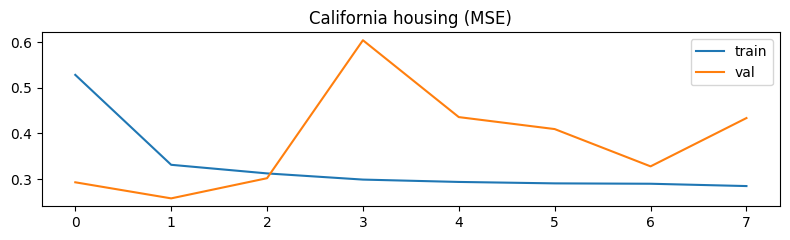

In [11]:
from sklearn.datasets import fetch_california_housing

CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

ch = fetch_california_housing()
X_ch = ch.data.astype(np.float32)
y_ch = ch.target.astype(np.float32).reshape(-1, 1)
sc_x_ch = StandardScaler()
sc_y_ch = StandardScaler()
X_ch = sc_x_ch.fit_transform(X_ch).astype(np.float32)
y_ch = sc_y_ch.fit_transform(y_ch).astype(np.float32)
X_ch_tr, X_ch_temp, y_ch_tr, y_ch_temp = train_test_split(
    X_ch, y_ch, test_size=0.25, random_state=3
)
X_ch_va, X_ch_te, y_ch_va, y_ch_te = train_test_split(
    X_ch_temp, y_ch_temp, test_size=0.5, random_state=3
)

m_ch = build_fc_regression(X_ch.shape[1], 1, [128, 64], 0.2, lambda: ReLU())
m_ch.train()
hist_ch, test_ch = run_regression_experiment(
    "california_housing",
    m_ch,
    X_ch_tr,
    y_ch_tr,
    X_ch_va,
    y_ch_va,
    X_ch_te,
    y_ch_te,
    MSECriterion(),
    base_lr=1e-2,
    epochs=25,
    batch_size=128,
    warmup_steps=100,
    early=6,
    optimizer_ctor=lambda mod: Adam(mod, lr=1e-2),
    early_on="loss",
    checkpoint_path=CKPT_DIR / "reg_california_housing.npz",
)
print("California housing test:", test_ch)
plt.figure(figsize=(8, 2.5))
plt.plot(hist_ch["train_loss"], label="train")
plt.plot(hist_ch["val_loss"], label="val")
plt.title("California housing (MSE)")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# --- 2) MNIST: свёртки, пулы, flatten, log-softmax + NLL ---

try:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    Xm = mnist["data"].astype(np.float32) / 255.0
    ym = mnist["target"].astype(np.int64)
except Exception as e:
    print("OpenML MNIST failed:", e)
    raise

X_m = Xm.reshape(-1, 1, 28, 28)
y_m = ym
X_tr, X_temp, y_tr, y_temp = train_test_split(X_m, y_m, test_size=0.3, random_state=1)
X_va, X_te, y_va, y_te = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)


def one_hot(y, c):
    o = np.zeros((len(y), c), dtype=np.float32)
    o[np.arange(len(y)), y] = 1.0
    return o


def train_clf_epoch(model, X, y, crit, opt, batch, step_ref, base_lr, warmup_steps, total_steps):
    model.train()
    perm = np.random.permutation(len(X))
    losses = []
    for i in range(0, len(X), batch):
        xb = X[perm[i : i + batch]]
        yb = y[perm[i : i + batch]]
        yb_oh = one_hot(yb, 10)
        opt.lr = lr_cosine_with_warmup(step_ref[0], base_lr, warmup_steps, total_steps)
        model.zeroGradParameters()
        pred = model.forward(xb)
        loss = crit.forward(pred, yb_oh)
        g = crit.backward(pred, yb_oh)
        model.backward(xb, g)
        opt.step()
        step_ref[0] += 1
        losses.append(loss)
    return float(np.mean(losses))


def build_mnist_cnn(use_softmax=False):
    net = Sequential()
    net.add(Conv2d(1, 16, 3, padding="same", padding_mode="zeros"))
    net.add(ReLU())
    net.add(MaxPool2d(2, 2, 0))
    net.add(Conv2d(16, 32, 3, padding="same", padding_mode="zeros"))
    net.add(ReLU())
    net.add(MaxPool2d(2, 2, 0))
    net.add(Flatten(1, -1))
    net.add(Linear(32 * 7 * 7, 128))
    net.add(BatchNormalization(alpha=0.9))
    net.add(ChannelwiseScaling(128))
    net.add(ELU(alpha=1.0))
    net.add(Dropout(0.3))
    net.add(Linear(128, 10))
    if use_softmax:
        net.add(SoftMax())
    else:
        net.add(LogSoftMax())
    return net


def evaluate_clf_any(model, X, y, crit):
    was_training = model.training
    model.evaluate()
    pred = model.forward(X)
    y_oh = one_hot(y, 10)
    loss = float(crit.forward(pred, y_oh))
    acc = float(np.mean(np.argmax(pred, axis=1) == y))
    if was_training:
        model.train()
    return loss, acc


cnn = build_mnist_cnn(False)

crit_nll = ClassNLLCriterion()
opt_cnn = Adam(cnn, lr=3e-3)
EPOCHS_CNN = 12
BATCH_C = 128
steps = [0]
total_steps = EPOCHS_CNN * (len(X_tr) // BATCH_C + 1)
hist_c = {"train": [], "val_loss": [], "val_acc": []}
best_c = None
es_c = EarlyStopping(patience=4)

for ep in range(EPOCHS_CNN):
    if ep == 6:
        opt_cnn = SGD(cnn, lr=0.05, momentum=0.9)
        print("MNIST: смена Adam -> SGD, эпоха", ep)
    tl = train_clf_epoch(cnn, X_tr, y_tr, crit_nll, opt_cnn, BATCH_C, steps, 3e-3, 300, total_steps)
    vl, acc = evaluate_classification_logits(cnn, X_va, y_va, crit_nll)
    hist_c["train"].append(tl)
    hist_c["val_loss"].append(vl)
    hist_c["val_acc"].append(acc)
    if es_c.is_better(vl):
        best_c = copy_flat_params(cnn)
        save_checkpoint_npz(CKPT_DIR / "mnist_logsoftmax.npz", cnn)
    print(f"epoch {ep:02d} train {tl:.4f} val_loss {vl:.4f} val_acc {acc:.4f}")
    if es_c.should_stop():
        break

if best_c is not None:
    load_flat_params(cnn, best_c)
cnn.evaluate()
pred_te = cnn.forward(X_te)
y_oh_te = one_hot(y_te, 10)
test_loss = float(crit_nll.forward(pred_te, y_oh_te))
test_acc = float(np.mean(np.argmax(pred_te, axis=1) == y_te))
print("MNIST test:", test_loss, test_acc)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(hist_c["train"], label="train")
plt.plot(hist_c["val_loss"], label="val")
plt.title("NLL loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist_c["val_acc"], label="val acc")
plt.title("Val accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Дополнительно: SoftMax + ClassNLLCriterionUnstable (формулировка «софтмакс» из задания)
cnn_s = build_mnist_cnn(True)
crit_u = ClassNLLCriterionUnstable()
opt_s = Adam(cnn_s, lr=3e-3)
steps_s = [0]
EPOCHS_SM = 8
hist_s = {"train": [], "val_loss": [], "val_acc": []}
es_s = EarlyStopping(patience=3)
best_s = None
for ep in range(EPOCHS_SM):
    tl = train_clf_epoch(
        cnn_s, X_tr, y_tr, crit_u, opt_s, BATCH_C, steps_s, 3e-3, 300, total_steps
    )
    vl, acc = evaluate_clf_any(cnn_s, X_va, y_va, crit_u)
    hist_s["train"].append(tl)
    hist_s["val_loss"].append(vl)
    hist_s["val_acc"].append(acc)
    if es_s.is_better(vl):
        best_s = copy_flat_params(cnn_s)
        save_checkpoint_npz(CKPT_DIR / "mnist_softmax_unstable.npz", cnn_s)
    print(f"softmax ep {ep:02d} train {tl:.4f} val_loss {vl:.4f} val_acc {acc:.4f}")
    if es_s.should_stop():
        break
if best_s is not None:
    load_flat_params(cnn_s, best_s)
te_u, acc_u = evaluate_clf_any(cnn_s, X_te, y_te, crit_u)
print("MNIST SoftMax + unstable NLL test:", te_u, acc_u)



In [ ]:
# --- 3) Автоэнкодер MNIST: свёртки + FC + upsample + сигмоида ---

CKPT_DIR = ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

X_ae = X_m[:8000]
X_tr_ae, X_temp_ae = train_test_split(X_ae, test_size=0.2, random_state=2)
X_va_ae, X_te_ae = train_test_split(X_temp_ae, test_size=0.5, random_state=2)

enc_dec = Sequential()
enc_dec.add(Conv2d(1, 16, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(MaxPool2d(2, 2, 0))
enc_dec.add(Conv2d(16, 32, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(MaxPool2d(2, 2, 0))
enc_dec.add(Flatten(1, -1))
enc_dec.add(Linear(32 * 7 * 7, 128))
enc_dec.add(BatchNormalization(alpha=0.9))
enc_dec.add(ChannelwiseScaling(128))
enc_dec.add(ReLU())
enc_dec.add(Dropout(0.2))
enc_dec.add(Linear(128, 32 * 7 * 7))
enc_dec.add(Reshape(32, 7, 7))
enc_dec.add(NearestUpsample2d(2))
enc_dec.add(Conv2d(32, 16, 3, padding="same", padding_mode="zeros"))
enc_dec.add(ReLU())
enc_dec.add(NearestUpsample2d(2))
enc_dec.add(Conv2d(16, 1, 3, padding="same", padding_mode="zeros"))
enc_dec.add(Sigmoid())

mse_ae = MSECriterion()
opt_ae = Adam(enc_dec, lr=1e-3)
EPOCHS_AE = 15
BATCH_AE = 128
hist_ae = {"tr": [], "val": []}
best_ae = None
es_ae = EarlyStopping(patience=5)
step_ae = [0]
total_ae = EPOCHS_AE * (len(X_tr_ae) // BATCH_AE + 1)

for ep in range(EPOCHS_AE):
    if ep == 7:
        opt_ae = SGD(enc_dec, lr=0.02, momentum=0.9)
        print("AE: смена Adam -> SGD, эпоха", ep)
    enc_dec.train()
    perm = np.random.permutation(len(X_tr_ae))
    losses = []
    for i in range(0, len(X_tr_ae), BATCH_AE):
        xb = X_tr_ae[perm[i : i + BATCH_AE]]
        opt_ae.lr = lr_cosine_with_warmup(step_ae[0], 1e-3, 200, total_ae)
        enc_dec.zeroGradParameters()
        out = enc_dec.forward(xb)
        loss = mse_ae.forward(out, xb)
        g = mse_ae.backward(out, xb)
        enc_dec.backward(xb, g)
        opt_ae.step()
        step_ae[0] += 1
        losses.append(loss)
    vl = evaluate_ae(enc_dec, X_va_ae, mse_ae)
    hist_ae["tr"].append(float(np.mean(losses)))
    hist_ae["val"].append(vl)
    if es_ae.is_better(vl):
        best_ae = copy_flat_params(enc_dec)
        save_checkpoint_npz(CKPT_DIR / "autoencoder.npz", enc_dec)
    print(f"AE epoch {ep:02d} train {hist_ae['tr'][-1]:.5f} val {vl:.5f}")
    if es_ae.should_stop():
        break

if best_ae is not None:
    load_flat_params(enc_dec, best_ae)
enc_dec.evaluate()
test_mse = evaluate_ae(enc_dec, X_te_ae, mse_ae)
print("AE test MSE:", test_mse)
pred_ae_te = enc_dec.forward(X_te_ae)
mse_pix = float(np.mean((X_te_ae - pred_ae_te) ** 2))
psnr_db = 10.0 * np.log10(1.0 / max(mse_pix, 1e-12))
print("AE test PSNR (дБ, MAX=1):", psnr_db)

plt.figure(figsize=(6, 3))
plt.plot(hist_ae["tr"], label="train")
plt.plot(hist_ae["val"], label="val")
plt.title("Autoencoder MSE")
plt.legend()
plt.tight_layout()
plt.show()

n_show = 8
enc_dec.evaluate()
sample = X_te_ae[:n_show]
rec = enc_dec.forward(sample)
fig, axes = plt.subplots(2, n_show, figsize=(14, 3))
for i in range(n_show):
    axes[0, i].imshow(sample[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(rec[i, 0], cmap="gray")
    axes[1, i].axis("off")
plt.suptitle("Верх: оригинал, низ: восстановление")
plt.tight_layout()
plt.show()



In [ ]:
# Кратко: что сделано
# - Утилиты: save_checkpoint_npz / load_checkpoint_npz; early_on (loss) + файл при улучшении val.
# - Регрессия: small ReLU / medium LeakyReLU / large ELU; чекпоинты reg_*.npz; Adam→SGD и MSE→MAE с эпохи 20.
# - MNIST: основной CNN — LogSoftMax + ClassNLL; доп. прогон — SoftMax + ClassNLLUnstable; mnist_*.npz.
# - Автоэнкодер: Dropout в bottleneck, Adam->SGD с эпохи 7, PSNR, autoencoder.npz, картинки.
# - California housing: reg_california_housing.npz (реальные данные, одна цель).

